# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

Our playbook uses a hybrid scoring strategy that integrates statistical decline risk with rule-based operational signals. We rank candidates using a `final_refresh_score` defined as a weighted combination of the machine learning model's decline probability ($70\%$) and a normalized baseline refresh score ($30\%$) derived from GSC and GA4 trends.

### Action Mapping & Operational Intent
Every page is mapped to one of five strategic actions:
1. **`expand_and_refresh`**: Triggered when a page has thin content (`thin_visible_page`) but still receives search impressions. The objective is to expand the depth, add subtopics, definitions, and actual evidence rather than generic AI padding.
2. **`refresh_and_review_ctr`**: Triggered when a page ranks well (top 20) but has a low CTR ($< 0.5\%$) and is flagged by the model as a decline candidate. Copywriters should refine titles, meta descriptions, and search snippets to capture more clicks.
3. **`refresh_and_review_engagement`**: Triggered when a page has traffic but low scroll/engagement rates ($< 30\%$). Copywriters should improve readability, add a table of contents, and insert visual callouts to hold visitor attention.
4. **`refresh`**: General refresh triggered by stale publication dates, model risk, or general decline with high search demand. The page is queued for recrawl prep and factual updates.
5. **`monitor`**: Default action for pages with low risk and low priority.

Below, we load the features, baseline scores, and model predictions, merge them, calculate the final scores and action classes, and render a preview of the playbook queue.

=== Top 10 Ranked Actions in Playbook Queue ===
 final_rank  final_refresh_score       suggested_action confidence                                                                                                                                                   final_reason_codes  impressions_90d trend_direction
          1            81.928467 refresh_and_review_ctr       high declining_with_demand|low_ctr_visible_page|low_engagement_visible_page|model_decline_risk|visible_model_opportunity|ctr_review_candidate|engagement_review_candidate            12834            down
          2            81.728449 refresh_and_review_ctr       high                                                         declining_with_demand|low_ctr_visible_page|model_decline_risk|visible_model_opportunity|ctr_review_candidate             8064            down
          3            81.639118 refresh_and_review_ctr     medium                                                         declining_with_demand|low_ctr_visi

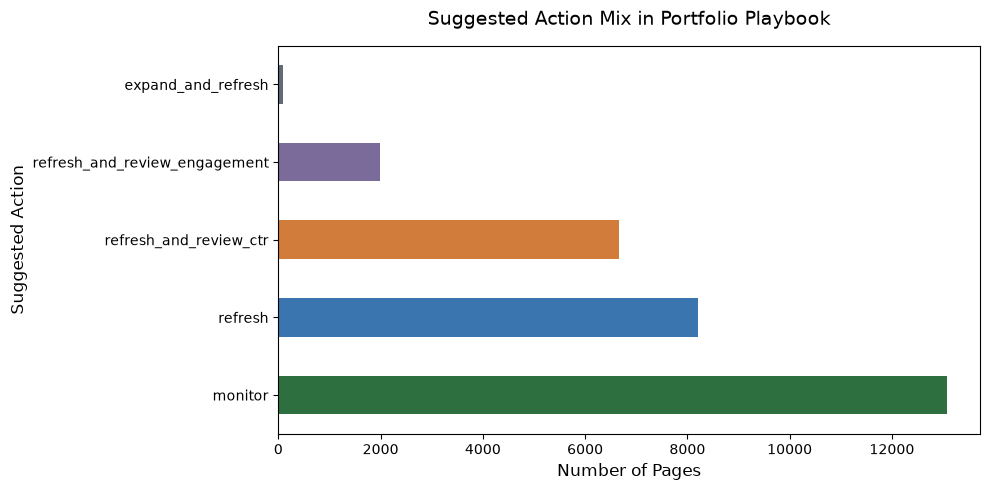

In [1]:
# Load libraries and create directories
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('../outputs/charts', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Load data
df_feat = pd.read_csv('../../data/processed/refresh_feature_vector.csv')
df_base = pd.read_csv('../../data/processed/baseline_refresh_queue.csv')
df_pred = pd.read_csv('../../data/processed/model_predictions.csv')

# Merge datasets
final_frame = df_base.merge(
    df_pred[[
        "content_id", "best_model_name", "best_model_probability",
        "prob_logistic_regression", "prob_decision_tree", "prob_random_forest"
    ]],
    on="content_id",
    how="left"
)

context_cols = ["content_id", "competition_level", "content_type", "main_intent", "age_tier", "freshness_tier", "word_count_tier", "impression_tier", "position_tier"]
final_frame = final_frame.merge(
    df_feat[[col for col in context_cols if col in df_feat.columns]],
    on="content_id",
    how="left"
)

final_frame["best_model_probability"] = final_frame["best_model_probability"].fillna(0)

# Normalize baseline score
b_min, b_max = final_frame["baseline_refresh_score"].min(), final_frame["baseline_refresh_score"].max()
final_frame["baseline_score_normalized"] = (final_frame["baseline_refresh_score"] - b_min) / (b_max - b_min) if b_max != b_min else 0.0

# Calculate final hybrid score
final_frame["final_refresh_score"] = (100 * (0.70 * final_frame["best_model_probability"] + 0.30 * final_frame["baseline_score_normalized"])).clip(0, 100)

# Merged reason codes logic
def merged_reason_codes(row):
    reasons = [r for r in str(row.get("reason_codes", "")).split("|") if r and r != "nan"]
    if row["best_model_probability"] >= 0.65:
        reasons.append("model_decline_risk")
    if row["best_model_probability"] >= 0.5 and row["impressions_90d"] >= 500:
        reasons.append("visible_model_opportunity")
    if row["impressions_90d"] >= 500 and row["avg_position"] > 0 and row["avg_position"] <= 20 and row["ctr"] < 0.5:
        reasons.append("ctr_review_candidate")
    if row["sessions_90d"] >= 30 and ((row["engagement_rate"] > 0 and row["engagement_rate"] < 30) or (row["scroll_rate"] > 0 and row["scroll_rate"] < 30)):
        reasons.append("engagement_review_candidate")
    unique_reasons = []
    for r in reasons:
        if r not in unique_reasons:
            unique_reasons.append(r)
    return "|".join(unique_reasons or ["general_refresh_review"])

final_frame["final_reason_codes"] = final_frame.apply(merged_reason_codes, axis=1)

# Suggested action mapping
def suggested_action(row):
    reasons = set(str(row["final_reason_codes"]).split("|"))
    if "thin_visible_page" in reasons:
        return "expand_and_refresh"
    if "ctr_review_candidate" in reasons and ("model_decline_risk" in reasons or "declining_with_demand" in reasons):
        return "refresh_and_review_ctr"
    if "engagement_review_candidate" in reasons and ("model_decline_risk" in reasons or "declining_with_demand" in reasons):
        return "refresh_and_review_engagement"
    if {"model_decline_risk", "declining_with_demand", "stale_visible_page", "visible_model_opportunity"}.intersection(reasons):
        return "refresh"
    return "monitor"

final_frame["suggested_action"] = final_frame.apply(suggested_action, axis=1)

# Assign confidence label based on quantiles
high_threshold = float(final_frame["final_refresh_score"].quantile(0.8))
medium_threshold = float(final_frame["final_refresh_score"].quantile(0.5))

def confidence_label(row, high_t, med_t):
    if row["final_refresh_score"] >= high_t and row["impressions_90d"] >= 500 and row["sessions_90d"] >= 10 and row["best_model_probability"] >= 0.5:
        return "high"
    if row["final_refresh_score"] >= med_t:
        return "medium"
    return "low"

final_frame["confidence"] = final_frame.apply(lambda row: confidence_label(row, high_threshold, medium_threshold), axis=1)

# Sort and rank
final_frame = final_frame.sort_values(
    ["final_refresh_score", "impressions_90d", "sessions_90d"],
    ascending=[False, False, False]
).reset_index(drop=True)
final_frame["final_rank"] = final_frame.index + 1

# Preview
print("=== Top 10 Ranked Actions in Playbook Queue ===")
preview_cols = ["final_rank", "final_refresh_score", "suggested_action", "confidence", "final_reason_codes", "impressions_90d", "trend_direction"]
print(final_frame[preview_cols].head(10).to_string(index=False))

# Plot and save Action Mix Bar Chart
plt.figure(figsize=(10, 5))
action_counts = final_frame["suggested_action"].value_counts()
colors = ['#2E6F40', '#3B75AF', '#D17C3B', '#7A6B9B', '#606C76']
action_counts.plot(kind='barh', color=colors[:len(action_counts)])
plt.title("Suggested Action Mix in Portfolio Playbook", fontsize=14, pad=15)
plt.xlabel("Number of Pages", fontsize=12)
plt.ylabel("Suggested Action", fontsize=12)
plt.tight_layout()
plt.savefig('../figures/action_mix.png', dpi=300)
plt.savefig('../outputs/charts/action_mix.svg')
plt.show()

## 2. Intended use and limits

### Intended Use
This action playbook is a **decision-support tool** for editorial prioritization. It identifies pages with high GSC/GA4 presence that exhibit statistically robust decay patterns, allowing content teams to direct limited writing resources toward the most critical opportunities.

### Performance & Operational Boundaries
1. **Unseen Sites Generalizability:** Under our client-holdout validation design, the Random Forest model's average precision drops by nearly $16\%$ (from $76.9\%$ to $61.0\%$) on unseen domains. This indicates a higher rate of false positives on new client sites. Playbook recommendations on new sites must be verified with extra manual scrutiny.
2. **Observational vs. Causal:** The scores represent associations in a retrospective snapshot. Re-writing a page flagged as high-risk will not *guarantee* a traffic increase unless search query demand remains stable.
3. **External Search Dynamics:** The model cannot predict macro shifts, such as Google search algorithm core updates, seasonal organic volume collapses, or brand-level GSC search volume penalties.

Below, we inspect how scores distribute across different user intents and content types.

=== Score Distribution by User Search Intent ===
               Avg Score  Page Count
main_intent                         
commercial     51.612190        4612
informational  51.996034       17235
navigational   37.474698          46
transactional  51.237668        5733
unknown        27.154444        2374

=== Score Distribution by Content Type ===
                    Avg Score  Page Count
content_type                             
comparison article  50.513099         697
feedly article      24.483456        2096
keyword article     51.736543       27207


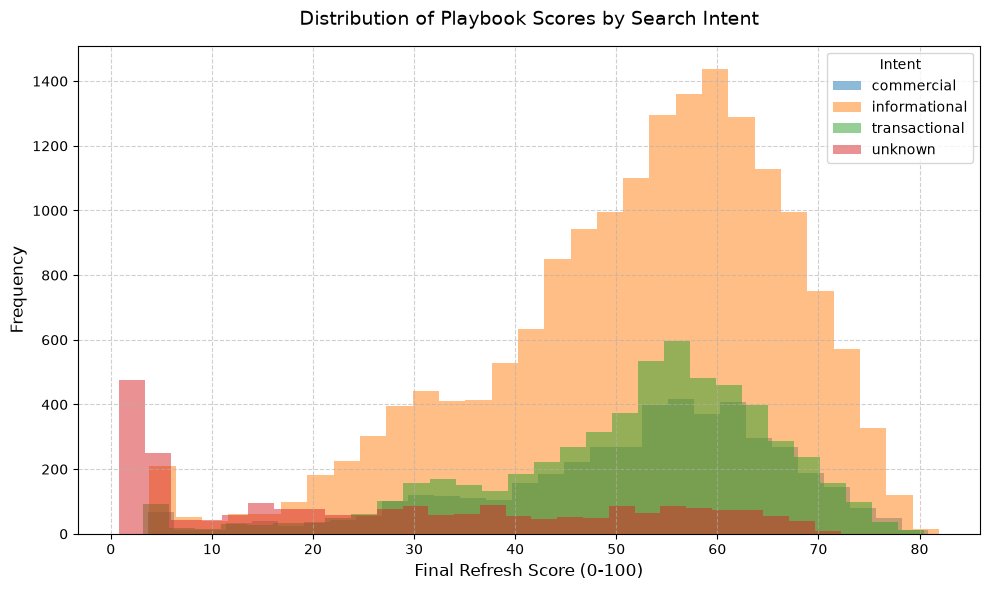

In [2]:
# Score Distribution by Intent and Content Type
print("=== Score Distribution by User Search Intent ===")
grouped_intent = final_frame.groupby("main_intent")["final_refresh_score"].agg(["mean", "count"]).rename(columns={"mean": "Avg Score", "count": "Page Count"})
print(grouped_intent.to_string())

print("\n=== Score Distribution by Content Type ===")
grouped_type = final_frame.groupby("content_type")["final_refresh_score"].agg(["mean", "count"]).rename(columns={"mean": "Avg Score", "count": "Page Count"})
print(grouped_type.to_string())

# Plot score distribution by search intent
plt.figure(figsize=(10, 6))
for name, group in final_frame.groupby("main_intent"):
    if len(group) > 50:
        plt.hist(group["final_refresh_score"], bins=30, alpha=0.5, label=name)
plt.title("Distribution of Playbook Scores by Search Intent", fontsize=14, pad=15)
plt.xlabel("Final Refresh Score (0-100)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(title="Intent")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../figures/score_distribution_by_intent.png', dpi=300)
plt.show()

## 3. Human review + the no-go list

### Human Review Rules
Prior to executing any playbook recommendation, a reviewer must verify:
1. **Query Intent Match:** Ensure the user search intent for the primary keyword has not shifted. For example, if a query evolved from informational to transactional, a simple text refresh will fail; the layout itself must change.
2. **Keyword Cannibalization:** Verify that a newer article on the domain has not been published targeting the exact same query, which would split the organic traffic.
3. **Factual Integrity:** Review statistics, links, and product details manually to maintain brand trust.

### Banned from Automation (The No-Go List)
* **LLM Auto-Rewriting & Publishing:** Banned from auto-regenerating page copy and publishing it directly without a human editor. Google's spam policies actively penalize programmatically generated low-quality content.
* **Auto-Redirects/Auto-Deletions:** Low-scoring pages should never be auto-deleted or auto-redirected algorithms. Low-traffic pages still carry brand authority or direct backlinks; deleting them can result in immediate loss of domain authority.
* **Algorithmic Keyword Density Tuning:** Automated query insertion to optimize keyword densities must be prohibited as it damages readability and violates search guidelines.

Below, we filter the queue for high-priority review candidates that rank well but have a high decline risk alongside a low CTR (< 0.3%) or poor engagement.

In [3]:
# Filter candidates requiring urgent manual review
print("=== High-Priority Human Review Candidates ===")

# Filtering rules: high-confidence, high impressions (>= 1000), but very low CTR (< 0.3%) or engagement flags
review_candidates = final_frame[
    (final_frame["confidence"] == "high") & 
    (final_frame["impressions_90d"] >= 1000) & 
    ((final_frame["ctr"] < 0.3) | (final_frame["final_reason_codes"].str.contains("engagement_review_candidate")))
].copy()

# Sort by final score
review_candidates = review_candidates.sort_values("final_refresh_score", ascending=False)

print(f"Total priority candidates requiring manual intent/cannibalization audit: {len(review_candidates)}")
print("\nTop 5 Candidates for Manual Audit:")
print(review_candidates[["final_rank", "content_id", "final_refresh_score", "suggested_action", "impressions_90d", "ctr", "final_reason_codes"]].head(5).to_string(index=False))

=== High-Priority Human Review Candidates ===
Total priority candidates requiring manual intent/cannibalization audit: 3019

Top 5 Candidates for Manual Audit:
 final_rank           content_id  final_refresh_score       suggested_action  impressions_90d  ctr                                                                                                                                                   final_reason_codes
          1 content_1f080331fa2b            81.928467 refresh_and_review_ctr            12834 0.05 declining_with_demand|low_ctr_visible_page|low_engagement_visible_page|model_decline_risk|visible_model_opportunity|ctr_review_candidate|engagement_review_candidate
          2 content_6aa43079fb0c            81.728449 refresh_and_review_ctr             8064 0.07                                                         declining_with_demand|low_ctr_visible_page|model_decline_risk|visible_model_opportunity|ctr_review_candidate
          5 content_72e800a9c214            80.8

## 4. Monitoring / retrain triggers

To prevent the model from drifting and providing stale recommendations, we implement three system triggers:
1. **Feature Drift Trigger:** If the portfolio-wide mean CTR, scroll rate, or AI session share shifts by more than $15\%$, the recommendations should be paused for auditing.
2. **Model Performance Trigger:** If rolling precision@50 monitored on updated pages falls below $55\%$, a retrain pipeline must be initiated.
3. **Google Search Console Core Updates:** Any major announced core update from Google should immediately invalidate the current model weights, triggering a re-validation and retraining pass.

Below, we output the reference feature distributions from this training batch to serve as the baseline configuration for future drift detection.

In [4]:
# Output feature baseline statistics for monitoring
print("=== Model Feature Baseline Reference ===")

features_to_monitor = [
    "search_volume", "competition", "cpc", "word_count",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct"
]

drift_reference = df_feat[features_to_monitor].agg(["mean", "std", "min", "max"]).T
print(drift_reference.to_string())

# Save drift reference to JSON for automated system checks
os.makedirs('../outputs', exist_ok=True)
drift_reference.to_json('../outputs/drift_monitoring_reference.json', orient='index', indent=2)
print("\nSaved drift monitoring reference to: work/outputs/drift_monitoring_reference.json")

=== Model Feature Baseline Reference ===


                        mean          std  min       max
search_volume     145.811667  1455.132022  0.0  74000.00
competition         0.134865     0.276223  0.0      1.00
cpc                 0.445415     2.017670  0.0    100.36
word_count       2310.205433  1846.788556  0.0   9546.00
ctr                 0.510733     3.279162  0.0    100.00
avg_position       16.342380    15.216790  0.0    245.00
engagement_rate     2.534520     8.310096  0.0    100.00
scroll_rate        18.137034    29.434690  0.0    300.00
ai_traffic_pct      0.768196     7.429454  0.0    300.00

Saved drift monitoring reference to: work/outputs/drift_monitoring_reference.json


## 5. Exports for the paper

We write the outputs of this playbook analysis to `work/outputs/` and save the figures to `work/figures/` (tracked in git) for reuse in the capstone research paper.

* **Playbook Queue CSV:** `work/outputs/refresh_queue.csv` (contains final ranks, scores, action mappings, and reason codes).
* **Charts:** `work/figures/action_mix.png` and `work/figures/confidence_mix.png`.
* **Summary JSON:** `work/outputs/summary.json` (receipt of playbook metrics).

Exported final playbook queue: ../outputs/refresh_queue.csv (Rows: 30000)


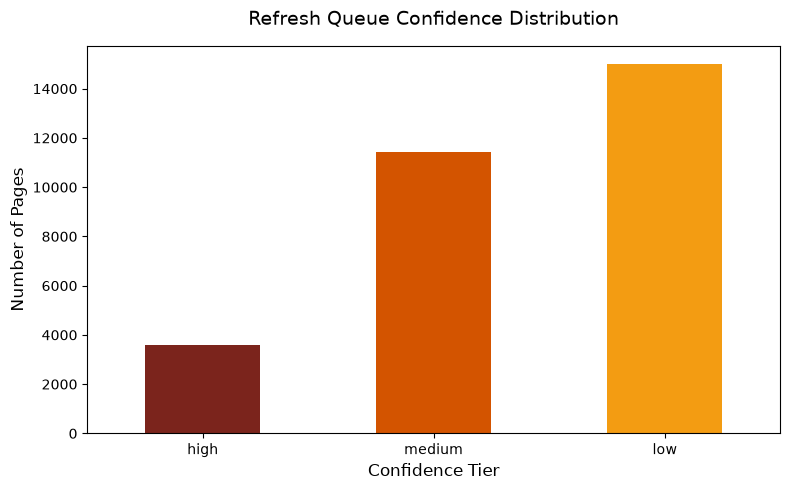


=== Model Metrics Receipt ===
Input Rows Scored: 30000
Validation Strategy: client_holdout
Best Model Selected: random_forest


In [5]:
# Export outputs for the paper
import json

# Output queue to CSV
output_columns = [
    "final_rank", "content_id", "client_id", "final_refresh_score",
    "best_model_name", "best_model_probability", "baseline_refresh_score",
    "confidence", "suggested_action", "final_reason_codes", "is_declining_label",
    "impressions_90d", "clicks_90d", "sessions_90d", "avg_position", "ctr",
    "content_age_days", "days_since_last_update", "word_count", "trend_direction",
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier"
]

queue_path = "../outputs/refresh_queue.csv"
final_frame[output_columns].to_csv(queue_path, index=False)
print(f"Exported final playbook queue: {queue_path} (Rows: {len(final_frame)})")

# Save Confidence Mix Plot
plt.figure(figsize=(8, 5))
conf_counts = final_frame["confidence"].value_counts().reindex(["high", "medium", "low"], fill_value=0)
conf_counts.plot(kind='bar', color=['#7B241C', '#D35400', '#F39C12'])
plt.title("Refresh Queue Confidence Distribution", fontsize=14, pad=15)
plt.ylabel("Number of Pages", fontsize=12)
plt.xlabel("Confidence Tier", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/confidence_mix.png', dpi=300)
plt.savefig('../outputs/charts/confidence_mix.svg')
plt.show()

# Read the metrics file to display metrics receipt
try:
    with open('../../outputs/model_results.json', 'r') as f:
        model_results = json.load(f)
    print("\n=== Model Metrics Receipt ===")
    print(f"Input Rows Scored: {model_results['input_rows']}")
    print(f"Validation Strategy: {model_results['split_strategy']}")
    print(f"Best Model Selected: {model_results['best_model']['name']}")
except Exception as e:
    print(f"Could not load model results: {e}")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.